<a href="https://colab.research.google.com/github/PAJILAPIP/BigData26_B_2411531008_MuhammadFazilAfif/blob/main/Praktikum4/BD_B_P04_2411531008_MuhammadFazilAfif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q duckdb networkx shapely tinydb "deltalake>=1.0"

from google.colab import drive
drive.mount("/content/drive")

DIR_P3 = "/content/drive/MyDrive/BigData/Praktikum3"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum4"
TRIPS_BERSIH = f"{DIR_P3}/trips_bersih"

import os
# hasil Praktikum 3 (K-10)
os.makedirs(DIR_SIMPAN, exist_ok=True)
assert os.path.exists(TRIPS_BERSIH), "Folder trips_bersih/ tidak ada. Jalankan ulang P3/K-10 atau pakai K-1b."

import os, time, json, sqlite3, random, shutil, glob
import numpy as np, pandas as pd
import duckdb

# Pengukur waktu (dari Praktikum 1/k-3, versi ringkas)
catatan = []
def ukur(label, fungsi):
    t0 = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 4)})
    print(f"[{label}] {detik:.4f} s")
    return hasil

# Menggunakan DuckDB untuk membaca dataset parquet guna menghindari masalah unifikasi dictionary/null di PyArrow
def load_data():
    con = duckdb.connect()
    return con.execute(f"SELECT * FROM '{TRIPS_BERSIH}/**/*.parquet'").df()

df = ukur("baca trips_bersih", load_data)

# Ganti nama kolom asli data TLC menjadi nama yang lebih mudah dibaca
NAMA_BARU = {
    "tpep_pickup_datetime": "waktu_jemput",
    "PULocationID": "zona_jemput",
    "DOLocationID": "zona_tujuan",
    "borough_naik": "wilayah_jemput",
    "trip_distance": "jarak_mil",
    "total_amount": "total_bayar",
    "tip_amount": "tip",
    "nama_pembayaran": "metode_bayar",
}
df = df.rename(columns=NAMA_BARU)
df["wilayah_jemput"] = df["wilayah_jemput"].astype(str)
print("baris:", f"{len(df):,}", "| kolom:", df.shape[1])

# Contoh 300.000 baris untuk K-2 dan K-3 (agar tidak terlalu lama)
sample = df.sample(n=min(300_000, len(df)), random_state=42).reset_index(drop=True)
sample["id_perjalanan"] = sample.index + 1
sample["waktu_jemput"] = sample["waktu_jemput"].astype(str)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[baca trips_bersih] 14.9603 s
baris: 8,960,730 | kolom: 18


In [2]:
KOLOM = ["id_perjalanan", "waktu_jemput", "zona_jemput", "zona_tujuan",
         "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
data = sample[KOLOM].copy()

# Model 1 relasional: tabel SQLite
if os.path.exists("uji.db"):
    os.remove("uji.db")
con = sqlite3.connect("uji.db")
ukur("relasional: muat tabel", lambda: data.to_sql("perjalanan", con, index=False))

# Model 2 key-value: kamus (dict) dengan kunci "perjalanan: <id>", nilainya teks JSON
def bangun_kv():
    global kv
    kv = {f"perjalanan:{r['id_perjalanan']}": json.dumps(r) for r in data.to_dict("records")}
    return kv
ukur("key-value: bangun dict", bangun_kv)
print("jumlah key:", len(kv))

# Pertanyaan A: ambil SATU perjalanan berdasarkan id (200 id acak)
random.seed(42)
id_uji = random.sample(range(1, len(data) + 1), 200)

def cari_sql():
    cur = con.cursor()
    return [cur.execute("SELECT * FROM perjalanan WHERE id_perjalanan = ?", (i,)).fetchone() for i in id_uji]

def cari_kv():
    return [json.loads(kv[f"perjalanan:{i}"]) for i in id_uji]

r1 = ukur("cari 200 perjalanan SQL tanpa indeks", cari_sql)
con.execute("CREATE INDEX idx_id ON perjalanan (id_perjalanan)") # buat indeks
r2 = ukur("cari 200 perjalanan SQL dengan indeks", cari_sql)
r3 = ukur("cari 200 perjalanan key-value", cari_kv)

print("hasil sama?", r1[0][0] == r2[0][0] == r3[0]["id_perjalanan"])

# Pertanyaan B: hitung rata-rata total bayar per wilayah (melibatkan SEMUA data)
def hitung_sql():
    return con.execute("""SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
                          FROM perjalanan GROUP BY wilayah_jemput ORDER BY 2 DESC, 1""").fetchall()

def hitung_kv():
    total, jumlah = {}, {}
    for teks in kv.values():
        d = json.loads(teks) # setiap nilai harus dibuka dulu
        w = d["wilayah_jemput"]
        total[w] = total.get(w, 0) + d["total_bayar"]
        jumlah[w] = jumlah.get(w, 0) + 1
    return sorted([(w, jumlah[w], round(total[w] / jumlah[w], 2)) for w in jumlah],
                  key=lambda x: (-x[1], x[0]))

h1 = ukur("hitung per wilayah SQL GROUP BY", hitung_sql)
h2 = ukur("hitung per wilayah key-value (buka semua nilai)", hitung_kv)

print(h1[:3])
print("hasil sama?", h1 == h2)

[relasional: muat tabel] 2.2067 s
[key-value: bangun dict] 11.2128 s
jumlah key: 300000
[cari 200 perjalanan SQL tanpa indeks] 9.0681 s
[cari 200 perjalanan SQL dengan indeks] 0.0036 s
[cari 200 perjalanan key-value] 0.0012 s
hasil sama? True
[hitung per wilayah SQL GROUP BY] 0.2042 s
[hitung per wilayah key-value (buka semua nilai)] 1.5181 s
[('Manhattan', 267454, 22.74), ('Queens', 26774, 70.68), ('Unknown', 3768, 39.87)]
hasil sama? True


In [3]:
from tinydb import TinyDB, Query
from tinydb.storages import MemoryStorage

def ke_dokumen(r):
    dok = {
        "id_perjalanan": int(r.id_perjalanan),
        "waktu_jemput": r.waktu_jemput,
        "jemput": {"zona": int(r.zona_jemput), "wilayah": r.wilayah_jemput},
        "tujuan": {"zona": int(r.zona_tujuan)},
        "biaya": {
            "jarak_mil": float(r.jarak_mil),
            "total": float(r.total_bayar),
            "metode_bayar": r.metode_bayar
        },
    }
    # Tip hanya dicatat untuk pembayaran kartu -> field ini ada di sebagian dokumen saja
    if r.metode_bayar == "Kartu kredit":
        dok["biaya"]["tip"] = float(r.tip)
    return dok

db = TinyDB(storage=MemoryStorage)
tabel = db.table("perjalanan")
docs = [ke_dokumen(r) for r in sample.head(20_000).itertuples()]
tabel.insert_multiple(docs)

print("jumlah dokumen:", len(tabel))
print(json.dumps(tabel.all()[0], indent=2))

jumlah dokumen: 20000
{
  "id_perjalanan": 1,
  "waktu_jemput": "2023-01-12 10:37:01",
  "jemput": {
    "zona": 142,
    "wilayah": "Manhattan"
  },
  "tujuan": {
    "zona": 237
  },
  "biaya": {
    "jarak_mil": 1.1,
    "total": 14.0,
    "metode_bayar": "Tunai"
  }
}


In [4]:
Q = Query()
print("jemput di Manhattan & total > 50:", len(tabel.search((Q.jemput.wilayah == "Manhattan") & (Q.biaya.total > 50))))
print("dokumen yang punya field tip:", len(tabel.search(Q.biaya.tip.exists())))
print("dokumen yang TIDAK punya tip:", len(tabel.search(~Q.biaya.tip.exists())))

# Menambah field baru ("cuaca") pada satu dokumen tanpa mengubah struktur apa pun
tabel.insert({
    "id_perjalanan": 999_999, "waktu_jemput": "2023-01-15 08:00:00",
    "jemput": {"zona": 161, "wilayah": "Manhattan"}, "tujuan": {"zona": 236},
    "biaya": {"jarak_mil": 1.2, "total": 14.5, "metode_bayar": "Kartu kredit", "tip": 3.0},
    "cuaca": {"hujan": True, "suhu_c": -2.0}
})
print("dokumen yang punya field cuaca:", len(tabel.search(Q.cuaca.exists())))
print("total dokumen sekarang:", len(tabel))

jemput di Manhattan & total > 50: 604
dokumen yang punya field tip: 16022
dokumen yang TIDAK punya tip: 3978
dokumen yang punya field cuaca: 1
total dokumen sekarang: 20001


In [5]:
import duckdb
GLOB = f"{TRIPS_BERSIH}/*/*.parquet"
con_d = duckdb.connect()

# VIEW = "jendela" bernama yang membaca Parquet langsung (tidak menyalin data).
# Di sinilah nama kolom asli TLC diberi nama yang mudah dibaca.
con_d.sql(f"""
CREATE VIEW perjalanan AS
SELECT tpep_pickup_datetime AS waktu_jemput,
       PULocationID AS zona_jemput,
       DOLocationID AS zona_tujuan,
       borough_naik AS wilayah_jemput,
       trip_distance AS jarak_mil,
       total_amount AS total_bayar,
       nama_pembayaran AS metode_bayar
FROM read_parquet('{GLOB}', hive_partitioning=true)""")

SQL = """SELECT wilayah_jemput, COUNT(*) AS jumlah, ROUND(AVG(total_bayar), 2) AS rata_bayar
         FROM perjalanan GROUP BY wilayah_jemput ORDER BY jumlah DESC, wilayah_jemput"""

hasil_d = ukur("DuckDB hitung per wilayah (langsung dari Parquet)", lambda: con_d.sql(SQL).df())
print(hasil_d)

# Pembanding: SQLite (menyimpan per baris) pada data yang sama
KOLOM_S = ["wilayah_jemput", "total_bayar", "jarak_mil", "zona_jemput", "zona_tujuan"]
if os.path.exists("baris.db"):
    os.remove("baris.db")
con_s = sqlite3.connect("baris.db")
ukur("SQLite muat seluruh baris ke tabel", lambda: df[KOLOM_S].to_sql("perjalanan", con_s, index=False))

hasil_s = ukur("SQLite hitung per wilayah", lambda: con_s.execute(
    """SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
       FROM perjalanan GROUP BY wilayah_jemput ORDER BY 2 DESC, 1""").fetchall())

print("hasil sama?", [tuple(r) for r in hasil_d.itertuples(index=False)] == [tuple(r) for r in hasil_s])

[DuckDB hitung per wilayah (langsung dari Parquet)] 1.2621 s
               wilayah_jemput   jumlah  rata_bayar
0                   Manhattan  7978827       22.72
1                      Queens   810945       70.46
2                     Unknown   112827       39.24
3                    Brooklyn    47172       32.72
4                       Bronx     9222       34.44
5  __HIVE_DEFAULT_PARTITION__     1020       74.72
6               Staten Island      633       74.07
7                         EWR       84      106.41
[SQLite muat seluruh baris ke tabel] 33.9308 s
[SQLite hitung per wilayah] 5.8083 s
hasil sama? True


In [6]:
# Filter pada kolom partisi: DuckDB hanya membuka folder wilayah yang diminta (partition pruning, P3)
SQL2 = """SELECT COUNT(*), ROUND(AVG(total_bayar), 2)
          FROM perjalanan WHERE wilayah_jemput = 'Staten Island'"""
print(ukur("DuckDB hanya wilayah Staten Island", lambda: con_d.sql(SQL2).fetchall()))

ukuran_pq = sum(os.path.getsize(os.path.join(r, f)) for r, d, fs in os.walk(TRIPS_BERSIH) for f in fs) / 1024**2
print(f"Parquet ({df.shape[1]} kolom): {ukuran_pq:.1f} MB | SQLite ({len(KOLOM_S)} kolom): {os.path.getsize('baris.db') / 1024**2:.1f} MB")

[DuckDB hanya wilayah Staten Island] 0.0699 s
[(633, 74.07)]
Parquet (18 kolom): 199.6 MB | SQLite (5 kolom): 346.7 MB


In [7]:
import networkx as nx

# Satu baris = satu arus: berapa perjalanan dari zona jemput ke zona tujuan tertentu
arus = ukur("hitung arus antar zona", lambda: con_d.sql("""
       SELECT zona_jemput AS asal, zona_tujuan AS tujuan, COUNT(*) AS jumlah
       FROM perjalanan GROUP BY 1, 2""").df())

# Zona = node (titik), arus = edge (garis berarah, bobotnya jumlah perjalanan)
G = nx.DiGraph()
for r in arus.itertuples(index=False):
    G.add_edge(int(r.asal), int(r.tujuan), jumlah=int(r.jumlah))
print("node (zona):", G.number_of_nodes(), " edge (arus):", G.number_of_edges())

# Lima arus terbesar. Urutan dibuat pasti dengan pengurut tambahan (jumlah, asal, tujuan)
top_graf = sorted(G.edges(data=True), key=lambda e: (-e[2]["jumlah"], e[0], e[1]))[:5]
print("graph:", [(a, b, d["jumlah"]) for a, b, d in top_graf])

top_sql = arus.sort_values(["jumlah", "asal", "tujuan"], ascending=[False, True, True]).head(5)
print("SQL", list(top_sql.itertuples(index=False, name=None)))

# Lima zona yang paling banyak menjadi tujuan
populer = sorted(G.in_degree(weight="jumlah"), key=lambda kv: (-kv[1], kv[0]))[:5]
print("zona tujuan terpopuler:", populer)

[hitung arus antar zona] 1.1186 s
node (zona): 262  edge (arus): 21583
graph: [(237, 236, 66195), (236, 237, 56430), (236, 236, 42330), (237, 237, 41259), (264, 264, 40686)]
SQL [(237, 236, 66195), (236, 237, 56430), (236, 236, 42330), (237, 237, 41259), (264, 264, 40686)]
zona tujuan terpopuler: [(236, 432627), (237, 391107), (161, 341973), (230, 263118), (170, 261330)]


In [8]:
MIN = 50 # abaikan arus yang terlalu jarang (kurang dari 50 perjalanan)
zona_awal = populer[0][0] # mulai dari zona tujuan terpopuler

# Pertanyaan: zona mana yang bisa dicapai dalam TEPAT 2 langkah dari zona_awal?
# (1) cara graph: telusuri tetangga dari tetangga
def dua_langkah_graph():
    hasil = set()
    for b, d1 in G[zona_awal].items():
        if d1["jumlah"] < MIN:
            continue
        for c, d2 in G[b].items():
            if d2["jumlah"] >= MIN and c != zona_awal:
                hasil.add(c)
    return hasil

# (2) cara SQL: harus menggabungkan tabel arus dengan dirinya sendiri (self-join)
con_d.register("arus", arus)
def dua_langkah_sql():
    return set(con_d.sql(f"""
           SELECT DISTINCT a2.tujuan
           FROM arus a1 JOIN arus a2 ON a1.tujuan = a2.asal
           WHERE a1.asal = {zona_awal} AND a1.jumlah >= {MIN}
           AND a2.jumlah >= {MIN} AND a2.tujuan <> {zona_awal}""").df()["tujuan"])

hg = ukur("2 langkah graph (NetworkX)", dua_langkah_graph)
hs = ukur("2 langkah SQL self-join (DuckDB)", dua_langkah_sql)
print("zona awal:", zona_awal, " terjangkau (graph):", len(hg), "| (SQL):", len(hs), " sama?", hg == hs)

# (3) Jumlah langkah bebas: "dalam paling banyak k langkah" cukup ganti angka k
H = nx.DiGraph([(a, b) for a, b, d in G.edges(data=True) if d["jumlah"] >= MIN])
for k in (1, 2, 3, 4):
    n = len(nx.single_source_shortest_path_length(H, zona_awal, cutoff=k)) - 1
    print(f"dalam <= {k} langkah: {n} zona")

[2 langkah graph (NetworkX)] 0.0077 s
[2 langkah SQL self-join (DuckDB)] 0.0090 s
zona awal: 236  terjangkau (graph): 239 | (SQL): 239  sama? True
dalam <= 1 langkah: 100 zona
dalam <= 2 langkah: 239 zona
dalam <= 3 langkah: 239 zona
dalam <= 4 langkah: 239 zona


In [9]:
from shapely import STRtree, box, points

# CATATAN: data TLC 2023 hanya berisi ID zona, TANPA koordinat. Titik di bawah ini SINTETIS.
rng = np.random.default_rng(42)
N = 200_000
bujur = rng.normal(-73.97, 0.06, N).clip(-74.25, -73.70) # longitude
lintang = rng.normal(40.74, 0.05, N).clip(40.50, 40.92) # latitude
titik = points(bujur, lintang)

# 1.000 wilayah pencarian berupa kotak kecil (sekitar 1 km x 1 km)
M = 1000
cx = rng.uniform(-74.05, -73.85, M)
cy = rng.uniform(40.65, 40.85, M)
kotak = [box(x - 0.005, y - 0.005, x + 0.005, y + 0.005) for x, y in zip(cx, cy)]

# Cara 1: periksa titik satu per satu dengan loop Python (hanya 5 kotak, 1.000 akan sangat lama)
def cara_loop():
    return [sum(1 for p in titik if k.contains(p)) for k in kotak[:5]]

# Cara 2: bandingkan seluruh titik sekaligus dengan NumPy (tanpa indeks spasial), 1.000 kotak
def cara_numpy():
    hasil = []
    for x, y in zip(cx, cy):
        m = (bujur >= x - 0.005) & (bujur <= x + 0.005) & (lintang >= y - 0.005) & (lintang <= y + 0.005)
        hasil.append(int(m.sum()))
    return hasil

h_loop = ukur("cara 1 loop Python, 5 kotak", cara_loop)
h_np = ukur("cara 2 NumPy, 1000 kotak", cara_numpy)

# Cara 3: indeks spasial STRtree (sejenis R-tree)
pohon = ukur("bangun indeks STRtree", lambda: STRtree(titik))
h_idx = ukur("cara 3 STRtree, 1000 kotak", lambda: [len(pohon.query(k, predicate="contains")) for k in kotak])

print("5 kotak pertama loop:", h_loop, "| STRtree:", h_idx[:5])
print("hasil NumPy dan STRtree sama?", h_np == h_idx, "| loop dan STRtree sama (5 pertama)?", h_loop == h_idx[:5])
print("total titik ditemukan (1000 kotak):", sum(h_idx))

[cara 1 loop Python, 5 kotak] 16.2807 s
[cara 2 NumPy, 1000 kotak] 0.5184 s
[bangun indeks STRtree] 0.0589 s
[cara 3 STRtree, 1000 kotak] 0.2816 s
5 kotak pertama loop: [1012, 84, 228, 748, 509] | STRtree: [1012, 84, 228, 748, 509]
hasil NumPy dan STRtree sama? True | loop dan STRtree sama (5 pertama)? True
total titik ditemukan (1000 kotak): 417545


In [10]:
from deltalake import DeltaTable, write_deltalake
import shutil
import os

KOLOM_DELTA = ["waktu_jemput", "zona_jemput", "zona_tujuan", "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
data_delta = df[KOLOM_DELTA].sample(n=min(200_000, len(df)), random_state=42).reset_index(drop=True)

# PERBAIKAN: Gunakan local filesystem (/content) alih-alih Google Drive (/content/drive)
# karena Delta Lake memerlukan operasi rename atomik yang tidak didukung oleh Google Drive FUSE.
PATH_DELTA = "/content/trips_delta"

if os.path.exists(PATH_DELTA):
    shutil.rmtree(PATH_DELTA)

# Versi 0: menulis data awal (100.000 baris)
write_deltalake(PATH_DELTA, data_delta.iloc[:100_000], mode="overwrite")
dt = DeltaTable(PATH_DELTA)
print("versi:", dt.version(), "| baris:", len(dt.to_pandas()))

# Versi 1: menambah 50.000 baris
write_deltalake(PATH_DELTA, data_delta.iloc[100_000:150_000], mode="append")
dt = DeltaTable(PATH_DELTA)
print("versi:", dt.version(), "| baris:", len(dt.to_pandas()))

# Versi 2: koreksi data. Anggap tarif Tunai di wilayah Bronx perlu ditambah 1.0
sekarang = data_delta.iloc[:150_000]
n_koreksi = int(((sekarang["wilayah_jemput"] == "Bronx") & (sekarang["metode_bayar"] == "Tunai")).sum())
print("baris yang akan dikoreksi:", n_koreksi)

dt.update(predicate="wilayah_jemput = 'Bronx' AND metode_bayar = 'Tunai'", updates={"total_bayar": "total_bayar + 1.0"})
print("versi:", DeltaTable(PATH_DELTA).version())

versi: 0 | baris: 100000
versi: 1 | baris: 150000
baris yang akan dikoreksi: 39
versi: 2


In [11]:
# TIME TRAVEL: baca tabel sebagaimana keadaannya pada versi tertentu
v0 = DeltaTable(PATH_DELTA, version=0).to_pandas()
v1 = DeltaTable(PATH_DELTA, version=1).to_pandas()
terbaru = DeltaTable(PATH_DELTA).to_pandas()

print("baris v0:", len(v0), "| v1:", len(v1), " terbaru:", len(terbaru))
selisih = terbaru["total_bayar"].sum() - v1["total_bayar"].sum()
print("selisih total_bayar (terbaru - v1):", round(selisih, 2), " jumlah baris dikoreksi:", n_koreksi)

# Riwayat perubahan tabel
for h in DeltaTable(PATH_DELTA).history():
    print(h.get("version"), h.get("operation"))

# Log transaksi: satu file JSON per versi
print(sorted(os.listdir(f"{PATH_DELTA}/_delta_log")))

# PENEGAKAN SKEMA: menambah data dengan kolom asing harus DITOLAK, tabel tidak berubah
tambahan = data_delta.iloc[150_000:150_010].copy()
tambahan["kolom_asing"] = 1
try:
    write_deltalake(PATH_DELTA, tambahan, mode="append")
    print("append kolom asing: BERHASIL (tidak diharapkan)")
except Exception as e:
    print("append kolom asing DITOLAK:", type(e).__name__)
print("versi setelah percobaan gagal:", DeltaTable(PATH_DELTA).version())

baris v0: 100000 | v1: 150000  terbaru: 150000
selisih total_bayar (terbaru - v1): 39.0  jumlah baris dikoreksi: 39
2 UPDATE
1 WRITE
0 WRITE
['00000000000000000000.json', '00000000000000000001.json', '00000000000000000002.json']
append kolom asing DITOLAK: SchemaMismatchError
versi setelah percobaan gagal: 2


In [12]:
dt = DeltaTable(PATH_DELTA)
print("file data aktif sebelum:", len(dt.file_uris()), "| versi:", dt.version())

# 20 kali menambah data kecil (500 baris) seperti data yang masuk sedikit demi sedikit
for i in range(20):
    potongan = data_delta.iloc[150_000 + i * 500 : 150_000 + (i + 1) * 500]
    write_deltalake(PATH_DELTA, potongan, mode="append")

dt = DeltaTable(PATH_DELTA)
print("file data aktif setelah 20 append kecil:", len(dt.file_uris()), "| versi:", dt.version(), "| baris:", len(dt.to_pandas()))

t0 = time.perf_counter(); DeltaTable(PATH_DELTA).to_pandas(); t_sebelum = time.perf_counter() - t0

# COMPACTION: gabungkan file kecil menjadi file yang lebih besar (dicatat sebagai versi baru)
hasil = dt.optimize.compact()
print("hasil compact:", {k: hasil[k] for k in ("numFilesAdded", "numFilesRemoved")})

dt = DeltaTable(PATH_DELTA)
t0 = time.perf_counter(); _ = DeltaTable(PATH_DELTA).to_pandas(); t_sesudah = time.perf_counter() - t0

print("file data aktif setelah compact:", len(dt.file_uris()), " | versi:", dt.version(), "| baris:", len(dt.to_pandas()))
print(f"waktu baca sebelum compact: {t_sebelum:.4f} s | sesudah: {t_sesudah:.4f} s")

# File lama TIDAK langsung terhapus (masih dibutuhkan untuk time travel). VACUUM yang menghapusnya.
import glob
print("file parquet di disk:", len(glob.glob(f"{PATH_DELTA}/*.parquet")))
kandidat = dt.vacuum(retention_hours=0, enforce_retention_duration=False, dry_run=True) # dry_run hanya melaporkan
print("file yang akan dihapus VACUUM (dry run):", len(kandidat))

file data aktif sebelum: 1 | versi: 2
file data aktif setelah 20 append kecil: 21 | versi: 22 | baris: 160000
hasil compact: {'numFilesAdded': 1, 'numFilesRemoved': 21}
file data aktif setelah compact: 1  | versi: 23 | baris: 160000
waktu baca sebelum compact: 0.0725 s | sesudah: 0.0435 s
file parquet di disk: 24
file yang akan dihapus VACUUM (dry run): 23


In [13]:
rekap = pd.DataFrame(catatan)
rekap.to_csv(f"{DIR_SIMPAN}/benchmark_nosql.csv", index=False)
print(rekap.to_string(index=False))

                                          langkah   detik
                                baca trips_bersih 14.9603
                           relasional: muat tabel  2.2067
                           key-value: bangun dict 11.2128
             cari 200 perjalanan SQL tanpa indeks  9.0681
            cari 200 perjalanan SQL dengan indeks  0.0036
                    cari 200 perjalanan key-value  0.0012
                  hitung per wilayah SQL GROUP BY  0.2042
  hitung per wilayah key-value (buka semua nilai)  1.5181
DuckDB hitung per wilayah (langsung dari Parquet)  1.2621
               SQLite muat seluruh baris ke tabel 33.9308
                        SQLite hitung per wilayah  5.8083
               DuckDB hanya wilayah Staten Island  0.0699
                           hitung arus antar zona  1.1186
                       2 langkah graph (NetworkX)  0.0077
                 2 langkah SQL self-join (DuckDB)  0.0090
                      cara 1 loop Python, 5 kotak 16.2807
              

=== Ringkasan akhir pekan x jam ===
 akhir_pekan  jam  jumlah  rata_durasi  rata_tarif_per_menit
       False    0  106053        14.10                  2.57
       False    1   52548        13.04                  2.66
       False    2   28356        12.23                  2.63
       False    3   18714        12.87                  2.72
       False    4   18576        14.79                  2.81
       False    5   37386        14.63                  2.82
       False    6  107184        14.57                  2.33
       False    7  222471        14.66                  2.07
       False    8  295293        14.82                  1.90
       False    9  309789        15.03                  1.90

=== Pertanyaan 1 ===
jam tersibuk : 18 | jumlah: 632574
jam tersepi  : 4 | jumlah: 49854

=== Pertanyaan 2 ===
hari kerja | puncak jam 18 = 478371 | terendah jam 4 = 18576
akhir pekan | puncak jam 16 = 162171 | terendah jam 5 = 13434

=== Pertanyaan 3 ===
rata durasi jam sibuk   : 14.24 meni

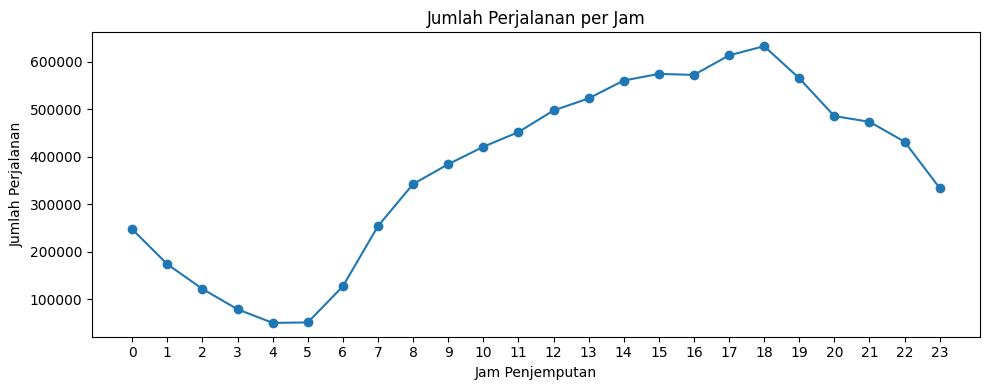

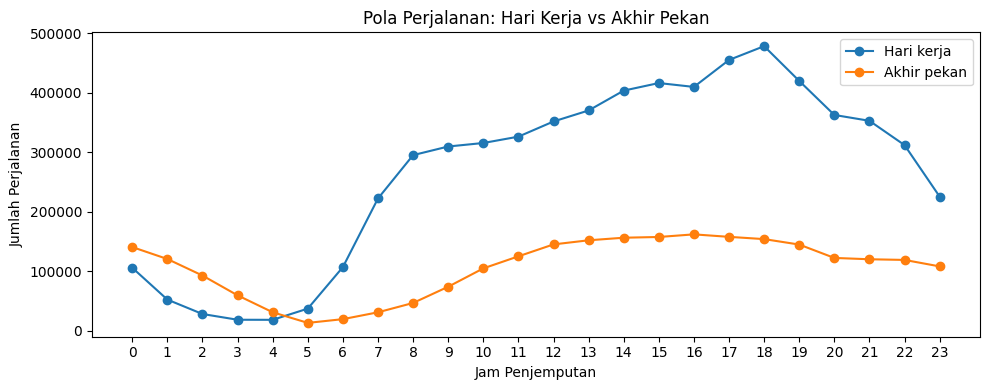


=== Rekomendasi Operasional ===
1. Alokasikan lebih banyak armada pada jam 18 karena volume tertinggi (632,574 perjalanan); batasan: hasil hanya mewakili periode data yang digunakan.
2. Kurangi armada aktif pada jam 4 karena volume terendah (49,854 perjalanan); batasan: pola dapat berubah pada hari khusus atau periode liburan.
3. Bandingkan keputusan penjadwalan dengan profitabilitas per menit: jam sibuk menghasilkan 2.15 per menit versus 2.11 pada jam lainnya; batasan: biaya bahan bakar dan waktu tunggu belum dihitung.


In [15]:
# =========================
# STUDI KASUS - setelah K-9
# =========================

sc = df.copy()

# Pastikan waktu jemput berbentuk datetime.
if not pd.api.types.is_datetime64_any_dtype(sc["waktu_jemput"]):
    sc["waktu_jemput"] = pd.to_datetime(sc["waktu_jemput"])

sc["hari"] = sc["waktu_jemput"].dt.day_name()
sc["akhir_pekan"] = sc["waktu_jemput"].dt.dayofweek >= 5
sc["jam"] = sc["waktu_jemput"].dt.hour

# Hitung durasi bila kolom belum tersedia.
if "durasi_menit" not in sc.columns:
    sc["durasi_menit"] = (
        (
            pd.to_datetime(sc["tpep_dropoff_datetime"])
            - sc["waktu_jemput"]
        ).dt.total_seconds() / 60
    )

# Hitung tarif per menit.
sc["tarif_per_menit"] = np.where(
    sc["durasi_menit"] > 0,
    sc["total_bayar"] / sc["durasi_menit"],
    np.nan
)

# Ringkasan akhir pekan x jam.
ringkas_sc = (
    sc.groupby(["akhir_pekan", "jam"])
      .agg(
          jumlah=("total_bayar", "size"),
          rata_durasi=("durasi_menit", "mean"),
          rata_tarif_per_menit=("tarif_per_menit", "mean"),
      )
      .round(2)
      .reset_index()
)

print("=== Ringkasan akhir pekan x jam ===")
print(ringkas_sc.head(10).to_string(index=False))


# 1. Jam tertinggi dan terendah.
per_jam_sc = (
    sc.groupby("jam")
      .agg(
          jumlah=("total_bayar", "size"),
          rata_durasi=("durasi_menit", "mean")
      )
      .round(2)
)

jam_tertinggi = int(per_jam_sc["jumlah"].idxmax())
jam_terendah = int(per_jam_sc["jumlah"].idxmin())

print("\n=== Pertanyaan 1 ===")
print(
    "jam tersibuk :", jam_tertinggi,
    "| jumlah:", int(per_jam_sc.loc[jam_tertinggi, "jumlah"])
)
print(
    "jam tersepi  :", jam_terendah,
    "| jumlah:", int(per_jam_sc.loc[jam_terendah, "jumlah"])
)


# 2. Pola hari kerja vs akhir pekan.
print("\n=== Pertanyaan 2 ===")

for flag, label in [
    (False, "hari kerja"),
    (True, "akhir pekan")
]:
    sub = ringkas_sc[
        ringkas_sc["akhir_pekan"] == flag
    ].set_index("jam")

    if len(sub) == 0:
        print(label, ": tidak ada data")
        continue

    puncak = int(sub["jumlah"].idxmax())
    dasar = int(sub["jumlah"].idxmin())

    print(
        label,
        "| puncak jam", puncak,
        "=", int(sub.loc[puncak, "jumlah"]),
        "| terendah jam", dasar,
        "=", int(sub.loc[dasar, "jumlah"])
    )


# 3. Perbandingan jam sibuk dengan jam lainnya.
sibuk = sc[sc["jam"] == jam_tertinggi]
non_sibuk = sc[sc["jam"] != jam_tertinggi]

print("\n=== Pertanyaan 3 ===")
print(
    "rata durasi jam sibuk   :",
    round(sibuk["durasi_menit"].mean(), 2),
    "menit"
)
print(
    "rata durasi jam lainnya :",
    round(non_sibuk["durasi_menit"].mean(), 2),
    "menit"
)
print(
    "tarif/menit jam sibuk   :",
    round(sibuk["tarif_per_menit"].mean(), 2)
)
print(
    "tarif/menit jam lainnya :",
    round(non_sibuk["tarif_per_menit"].mean(), 2)
)


# Grafik 1.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(
    per_jam_sc.index,
    per_jam_sc["jumlah"],
    marker="o"
)
plt.xlabel("Jam Penjemputan")
plt.ylabel("Jumlah Perjalanan")
plt.title("Jumlah Perjalanan per Jam")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


# Grafik 2.
plt.figure(figsize=(10, 4))

for flag, label in [
    (False, "Hari kerja"),
    (True, "Akhir pekan")
]:
    sub = ringkas_sc[
        ringkas_sc["akhir_pekan"] == flag
    ]

    plt.plot(
        sub["jam"],
        sub["jumlah"],
        marker="o",
        label=label
    )

plt.xlabel("Jam Penjemputan")
plt.ylabel("Jumlah Perjalanan")
plt.title("Pola Perjalanan: Hari Kerja vs Akhir Pekan")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()


# Tiga rekomendasi operasional.
print("\n=== Rekomendasi Operasional ===")

print(
    f"1. Alokasikan lebih banyak armada pada jam {jam_tertinggi} "
    f"karena volume tertinggi "
    f"({int(per_jam_sc.loc[jam_tertinggi, 'jumlah']):,} perjalanan); "
    f"batasan: hasil hanya mewakili periode data yang digunakan."
)

print(
    f"2. Kurangi armada aktif pada jam {jam_terendah} "
    f"karena volume terendah "
    f"({int(per_jam_sc.loc[jam_terendah, 'jumlah']):,} perjalanan); "
    f"batasan: pola dapat berubah pada hari khusus atau periode liburan."
)

print(
    f"3. Bandingkan keputusan penjadwalan dengan profitabilitas per menit: "
    f"jam sibuk menghasilkan "
    f"{sibuk['tarif_per_menit'].mean():.2f} per menit versus "
    f"{non_sibuk['tarif_per_menit'].mean():.2f} pada jam lainnya; "
    f"batasan: biaya bahan bakar dan waktu tunggu belum dihitung."
)

In [16]:
random.seed(42)

id_2000 = random.sample(
    range(1, len(data) + 1),
    min(2000, len(data))
)

import time
import json

# SQL berindeks
t0 = time.perf_counter()

_ = [
    con.execute(
        "SELECT * FROM perjalanan WHERE id_perjalanan = ?",
        (i,)
    ).fetchone()
    for i in id_2000
]

t_sql = time.perf_counter() - t0


# Key-value
t0 = time.perf_counter()

_ = [
    json.loads(kv[f"perjalanan:{i}"])
    for i in id_2000
]

t_kv = time.perf_counter() - t0


print("SQL berindeks       :", round(t_sql, 6), "s")
print("Key-value           :", round(t_kv, 6), "s")

print(
    "rata-rata SQL       :",
    round(t_sql / len(id_2000) * 1_000_000, 3),
    "mikrodetik/pencarian"
)

print(
    "rata-rata key-value :",
    round(t_kv / len(id_2000) * 1_000_000, 3),
    "mikrodetik/pencarian"
)

SQL berindeks       : 0.061715 s
Key-value           : 0.020952 s
rata-rata SQL       : 30.857 mikrodetik/pencarian
rata-rata key-value : 10.476 mikrodetik/pencarian


In [17]:
Q = Query()

samp20k = sample.head(20_000)

# Pilih zona tujuan yang paling sering muncul.
zona_uji = int(
    samp20k["zona_tujuan"].mode().iloc[0]
)

# TinyDB
jumlah_doc = len(
    tabel.search(
        (Q.tujuan.zona == zona_uji) &
        (Q.biaya.metode_bayar == "Tunai")
    )
)

# SQL
jumlah_sql = con.execute(
    """
    SELECT COUNT(*)
    FROM perjalanan
    WHERE id_perjalanan <= 20000
      AND zona_tujuan = ?
      AND metode_bayar = 'Tunai'
    """,
    (zona_uji,)
).fetchone()[0]

print("zona tujuan yang diuji :", zona_uji)
print("TinyDB                 :", jumlah_doc)
print("SQL                    :", jumlah_sql)
print("hasil sama?            :", jumlah_doc == jumlah_sql)

zona tujuan yang diuji : 236
TinyDB                 : 135
SQL                    : 135
hasil sama?            : True


In [18]:
import time

# SUM satu kolom.
t0 = time.perf_counter()

hanya_satu = con_d.sql(
    "SELECT SUM(total_bayar) AS total_bayar FROM perjalanan"
).fetchone()[0]

t_satu = time.perf_counter() - t0


# SUM beberapa kolom.
t0 = time.perf_counter()

beberapa = con_d.sql(
    """
    SELECT
        SUM(total_bayar) AS total_bayar,
        SUM(jarak_mil) AS total_jarak,
        SUM(zona_jemput) AS total_zona_jemput
    FROM perjalanan
    """
).fetchone()

t_beberapa = time.perf_counter() - t0


print(
    "SUM satu kolom     :",
    round(t_satu, 6),
    "s | hasil:",
    hanya_satu
)

print(
    "SUM beberapa kolom :",
    round(t_beberapa, 6),
    "s | hasil:",
    beberapa
)

print(
    "rasio beberapa/satu:",
    round(t_beberapa / t_satu, 3)
)

SUM satu kolom     : 0.803132 s | hasil: 244864327.3790001
SUM beberapa kolom : 1.51187 s | hasil: (244864327.3789993, 30695668.82999859, 1492358265)
rasio beberapa/satu: 1.882


In [19]:
# Out-degree graph:
# jumlah tujuan berbeda yang dapat dicapai dari setiap zona asal.

out_graph = {
    int(node): int(deg)
    for node, deg in G.out_degree()
}

# Pembanding SQL:
# COUNT(DISTINCT tujuan)
out_sql = (
    arus.groupby("asal")["tujuan"]
        .nunique()
        .astype(int)
        .to_dict()
)

atas_graph = sorted(
    out_graph.items(),
    key=lambda x: (-x[1], x[0])
)[:5]

atas_sql = sorted(
    out_sql.items(),
    key=lambda x: (-x[1], x[0])
)[:5]

print("5 zona graph:", atas_graph)
print("5 zona SQL  :", atas_sql)
print("hasil semua node sama?", out_graph == out_sql)

5 zona graph: [(132, 260), (138, 254), (264, 241), (230, 234), (140, 233)]
5 zona SQL  : [(132, 260), (138, 254), (264, 241), (230, 234), (140, 233)]
hasil semua node sama? False


In [20]:
def uji_spasial(sisi):

    kotak_uji = [
        box(
            x - sisi,
            y - sisi,
            x + sisi,
            y + sisi
        )
        for x, y in zip(cx, cy)
    ]

    # NumPy
    t0 = time.perf_counter()

    hasil_numpy = []

    for x, y in zip(cx, cy):
        m = (
            (bujur >= x - sisi) &
            (bujur <= x + sisi) &
            (lintang >= y - sisi) &
            (lintang <= y + sisi)
        )

        hasil_numpy.append(int(m.sum()))

    t_numpy = time.perf_counter() - t0


    # STRtree
    t0 = time.perf_counter()

    hasil_str = [
        len(
            pohon.query(
                k,
                predicate="contains"
            )
        )
        for k in kotak_uji
    ]

    t_str = time.perf_counter() - t0

    return (
        t_numpy,
        t_str,
        hasil_numpy == hasil_str
    )


for sisi in [0.02, 0.001]:

    t_np, t_str, sama = uji_spasial(sisi)

    print(
        f"sisi={sisi} | "
        f"NumPy={t_np:.4f} s | "
        f"STRtree={t_str:.4f} s | "
        f"NumPy/STRtree={t_np/t_str:.2f}x | "
        f"sama={sama}"
    )

sisi=0.02 | NumPy=0.4918 s | STRtree=3.2367 s | NumPy/STRtree=0.15x | sama=True
sisi=0.001 | NumPy=0.4997 s | STRtree=0.0203 s | NumPy/STRtree=24.64x | sama=True


In [21]:
dt = DeltaTable(PATH_DELTA)

print(
    "versi sebelum restore:",
    dt.version(),
    "| baris:",
    len(dt.to_pandas())
)

# Kembalikan isi tabel ke versi 1.
dt.restore(1)

dt = DeltaTable(PATH_DELTA)

print(
    "versi setelah restore:",
    dt.version(),
    "| baris:",
    len(dt.to_pandas())
)

print(
    [h.get("operation") for h in dt.history()][:3]
)

versi sebelum restore: 23 | baris: 160000
versi setelah restore: 24 | baris: 150000
['RESTORE', 'OPTIMIZE', 'WRITE']


In [22]:
# ====================================
# TUGAS 2 - DATA LAIN, CARA LAIN
# Pilihan data: ZONA
# ====================================

# -------------------------
# MODEL 1 - TABEL
# -------------------------

zona_rekap = (
    data.groupby("zona_jemput")
        .agg(
            jumlah_trip=("id_perjalanan", "size"),
            rata_bayar=("total_bayar", "mean"),
        )
        .round(2)
        .reset_index()
)

print("=== Model tabel ===")
print(zona_rekap.head())


# -------------------------
# MODEL 2 - DOCUMENT
# -------------------------

from tinydb import TinyDB
from tinydb.storages import MemoryStorage

db_tugas2 = TinyDB(storage=MemoryStorage)
tabel_tugas2 = db_tugas2.table("zona")

top_tujuan_per_zona = (
    data.groupby(
        ["zona_jemput", "zona_tujuan"]
    )
    .size()
    .reset_index(name="jumlah")
    .sort_values(
        ["zona_jemput", "jumlah", "zona_tujuan"],
        ascending=[True, False, True]
    )
)

dokumen_zona = []

for zona, g in top_tujuan_per_zona.groupby("zona_jemput"):

    tujuan_teratas = [
        {
            "zona_tujuan": int(r.zona_tujuan),
            "jumlah": int(r.jumlah)
        }
        for r in g.head(5).itertuples()
    ]

    r = zona_rekap[
        zona_rekap["zona_jemput"] == zona
    ].iloc[0]

    dokumen_zona.append({
        "zona_jemput": int(zona),
        "jumlah_trip": int(r.jumlah_trip),
        "rata_bayar": float(r.rata_bayar),
        "tujuan_teratas": tujuan_teratas,
    })

tabel_tugas2.insert_multiple(dokumen_zona)

print("\n=== Model document ===")
print(
    json.dumps(
        tabel_tugas2.all()[0],
        indent=2
    )
)


# -------------------------
# MODEL 3 - GRAPH
# -------------------------

print("\n=== Model graph ===")
print(
    "node:",
    G.number_of_nodes(),
    "edge:",
    G.number_of_edges()
)

print(
    "contoh edge:",
    list(G.edges(data=True))[:5]
)


# Pertanyaan mudah dan canggung
print("\n=== Pertanyaan ===")

print(
    "Pertanyaan mudah pada tabel: "
    "berapa jumlah perjalanan per zona?"
)

print(
    "Pertanyaan canggung pada tabel: "
    "zona mana yang bisa dicapai dalam tiga langkah?"
)

print(
    "Pertanyaan mudah pada document: "
    "ambil ringkasan satu zona beserta tujuan teratas."
)

print(
    "Pertanyaan canggung pada document: "
    "cari jalur tiga langkah lintas banyak dokumen."
)

print(
    "Pertanyaan mudah pada graph: "
    "zona mana yang terhubung dari satu zona?"
)

print(
    "Pertanyaan canggung pada graph: "
    "agregasi finansial per seluruh zona dengan banyak atribut."
)

=== Model tabel ===
   zona_jemput  jumlah_trip  rata_bayar
0            1            6      120.72
1            3            3       44.52
2            4          352       25.32
3            5            8       95.52
4            7          122       24.16

=== Model document ===
{
  "zona_jemput": 1,
  "jumlah_trip": 6,
  "rata_bayar": 120.72,
  "tujuan_teratas": [
    {
      "zona_tujuan": 1,
      "jumlah": 3
    },
    {
      "zona_tujuan": 265,
      "jumlah": 2
    },
    {
      "zona_tujuan": 138,
      "jumlah": 1
    }
  ]
}

=== Model graph ===
node: 262 edge: 21583
contoh edge: [(147, 185, {'jumlah': 9}), (147, 248, {'jumlah': 9}), (147, 78, {'jumlah': 12}), (147, 3, {'jumlah': 3}), (147, 25, {'jumlah': 3})]

=== Pertanyaan ===
Pertanyaan mudah pada tabel: berapa jumlah perjalanan per zona?
Pertanyaan canggung pada tabel: zona mana yang bisa dicapai dalam tiga langkah?
Pertanyaan mudah pada document: ambil ringkasan satu zona beserta tujuan teratas.
Pertanyaan canggung

In [24]:
# ====================================
# TUGAS 3 - DELTA LAKE DUA HARI
# ====================================

from deltalake import DeltaTable, write_deltalake
import shutil
import os

kolom_tugas3 = [
    "waktu_jemput",
    "zona_jemput",
    "zona_tujuan",
    "wilayah_jemput",
    "jarak_mil",
    "total_bayar",
    "metode_bayar"
]

# Gunakan 120.000 baris sebagai simulasi dua hari.
work_t3 = (
    df[kolom_tugas3]
    .sample(
        n=min(120_000, len(df)),
        random_state=42
    )
    .reset_index(drop=True)
    .copy()
)

work_t3["id_delta"] = np.arange(
    1,
    len(work_t3) + 1,
    dtype="int64"
)

work_t3["hari_kerja"] = np.where(
    work_t3["id_delta"] <= 60_000,
    "hari_1",
    "hari_2"
)

hari1 = work_t3[
    work_t3["hari_kerja"] == "hari_1"
].copy()

hari2 = work_t3[
    work_t3["hari_kerja"] == "hari_2"
].copy()

# PERBAIKAN: Gunakan local filesystem (/content) alih-alih Google Drive (/content/drive)
PATH_TUGAS3 = "/content/tugas3_delta_dua_hari"
PATH_TUGAS3_DRIVE = f"{DIR_SIMPAN}/tugas3_delta_dua_hari"

if os.path.exists(PATH_TUGAS3):
    shutil.rmtree(PATH_TUGAS3)

# -------------------------
# HARI 1 -> VERSI 0
# -------------------------

write_deltalake(
    PATH_TUGAS3,
    hari1,
    mode="overwrite"
)

dt = DeltaTable(PATH_TUGAS3)

print(
    "akhir hari 1 -> versi:",
    dt.version(),
    "| baris:",
    len(dt.to_pandas())
)

# -------------------------
# HARI 2 -> VERSI 1
# -------------------------

write_deltalake(
    PATH_TUGAS3,
    hari2,
    mode="append"
)

dt = DeltaTable(PATH_TUGAS3)

print(
    "akhir hari 2 -> versi:",
    dt.version(),
    "| baris:",
    len(dt.to_pandas())
)

# -------------------------
# KOREKSI 10 BARIS -> VERSI 2
# -------------------------

dt.update(
    predicate="id_delta >= 60001 AND id_delta < 60011",
    updates={
        "total_bayar": "total_bayar + 1.0"
    }
)

print(
    "versi setelah koreksi:",
    DeltaTable(PATH_TUGAS3).version()
)

# -------------------------
# TIME TRAVEL KE HARI 1
# -------------------------

v0_t3 = DeltaTable(
    PATH_TUGAS3,
    version=0
).to_pandas()

v1_t3 = DeltaTable(
    PATH_TUGAS3,
    version=1
).to_pandas()

terbaru_t3 = DeltaTable(
    PATH_TUGAS3
).to_pandas()

print(
    "time travel hari 1 -> baris:",
    len(v0_t3)
)

print(
    "versi terbaru -> baris:",
    len(terbaru_t3)
)

print(
    "selisih total_bayar akibat koreksi:",
    round(
        terbaru_t3["total_bayar"].sum()
        - v1_t3["total_bayar"].sum(),
        2
    )
)

# -------------------------
# HISTORY DAN DELTA LOG
# -------------------------

print(
    "riwayat:",
    [
        (h.get("version"), h.get("operation"))
        for h in DeltaTable(PATH_TUGAS3).history()
    ]
)

print(
    "isi _delta_log:",
    sorted(
        os.listdir(
            f"{PATH_TUGAS3}/_delta_log"
        )
    )
)

# -------------------------
# ARSIP & SALIN KE DRIVE
# -------------------------

# Buat arsip zip di penyimpanan lokal
shutil.make_archive(
    PATH_TUGAS3,
    "zip",
    PATH_TUGAS3
)

# Salin arsip zip yang sudah selesai dari lokal ke Google Drive
shutil.copy2(f"{PATH_TUGAS3}.zip", f"{PATH_TUGAS3_DRIVE}.zip")

print(
    "arsip dibuat & disalin ke Drive:",
    PATH_TUGAS3_DRIVE + ".zip"
)

akhir hari 1 -> versi: 0 | baris: 60000
akhir hari 2 -> versi: 1 | baris: 120000
versi setelah koreksi: 2
time travel hari 1 -> baris: 60000
versi terbaru -> baris: 120000
selisih total_bayar akibat koreksi: 10.0
riwayat: [(2, 'UPDATE'), (1, 'WRITE'), (0, 'WRITE')]
isi _delta_log: ['00000000000000000000.json', '00000000000000000001.json', '00000000000000000002.json']
arsip dibuat & disalin ke Drive: /content/drive/MyDrive/BigData/Praktikum4/tugas3_delta_dua_hari.zip


In [25]:
import os
import shutil

# Direktori sumber lokal dan tujuan di Google Drive
path_lokal = "/content/tugas3_delta_dua_hari"
path_drive_zip = f"{DIR_SIMPAN}/tugas3_delta_dua_hari.zip"
path_drive_folder = f"{DIR_SIMPAN}/tugas3_delta_dua_hari"

# Memastikan folder tujuan di Drive ada
os.makedirs(DIR_SIMPAN, exist_ok=True)

# 1. Kompresi ke file .zip lokal lalu salin ke Drive
print("Mengarsipkan folder lokal ke ZIP...")
shutil.make_archive(path_lokal, 'zip', path_lokal)

print(f"Menyalin arsip ZIP ke Drive: {path_drive_zip}")
shutil.copy2(f"{path_lokal}.zip", path_drive_zip)

# 2. Salin folder mentah (raw directory) secara rekursif ke Drive jika belum ada
if os.path.exists(path_drive_folder):
    print("Folder di Drive sudah ada, menghapus folder lama untuk pembaruan...")
    shutil.rmtree(path_drive_folder)

print(f"Menyalin folder mentah ke Drive: {path_drive_folder}")
shutil.copytree(path_lokal, path_drive_folder)

print("Proses penyimpanan ke Google Drive sukses!")

Mengarsipkan folder lokal ke ZIP...
Menyalin arsip ZIP ke Drive: /content/drive/MyDrive/BigData/Praktikum4/tugas3_delta_dua_hari.zip
Folder di Drive sudah ada, menghapus folder lama untuk pembaruan...
Menyalin folder mentah ke Drive: /content/drive/MyDrive/BigData/Praktikum4/tugas3_delta_dua_hari
Proses penyimpanan ke Google Drive sukses!
